In [8]:
import pandas as pd

# Define the column names manually
column_names = ['Tweet ID', 'Game', 'Sentiment', 'Tweet']

# Load the CSV file without headers and assign the column names
df = pd.read_csv('twitter_training.csv', header=None, names=column_names)

# Display the first few rows of the dataframe
print(df.head())

   Tweet ID         Game Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


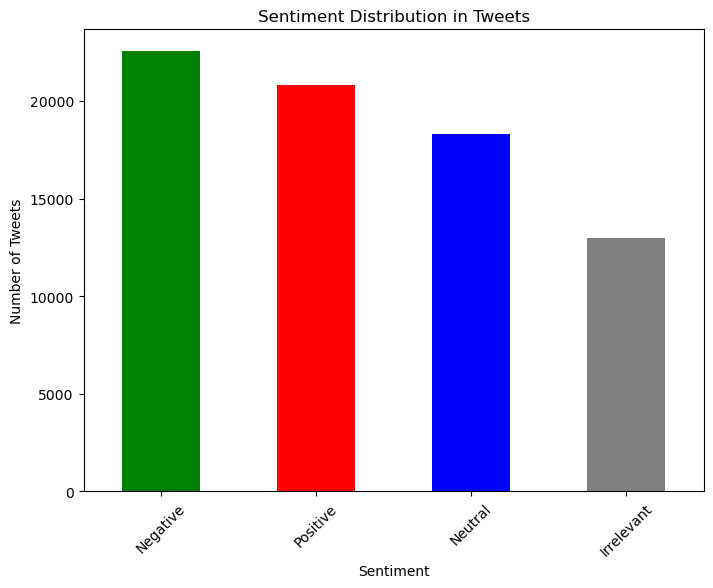

In [10]:
# Count the number of tweets per sentiment
sentiment_counts = df['Sentiment'].value_counts()

# Plot the sentiment distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue', 'gray'])
plt.title('Sentiment Distribution in Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.show()

In [19]:
# Check if other games are mentioned in the tweets
other_games = df[~df['Game'].str.contains('Borderlands', case=False, na=False)]
print(f"Number of tweets mentioning other games: {len(other_games)}")

Number of tweets mentioning other games: 72396


In [27]:
import numpy as np

# Ensure non-string values are handled properly
df['Tweet Length'] = df['Tweet'].apply(lambda x: len(str(x)) if isinstance(x, str) or isinstance(x, float) else 0)

# Alternatively, if you want to treat NaN as empty string:
df['Tweet Length'] = df['Tweet'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)


In [21]:
from collections import Counter
import re

# Function to clean and tokenize tweets
def clean_tweet(tweet):
    tweet = re.sub(r'http\S+', '', tweet)  # Remove URLs
    tweet = re.sub(r'[^\w\s]', '', tweet)  # Remove punctuation
    tweet = tweet.lower()  # Convert to lowercase
    return tweet.split()

# Get all positive and negative tweets
positive_tweets = df[df['Sentiment'] == 'Positive']['Tweet']
negative_tweets = df[df['Sentiment'] == 'Negative']['Tweet']

# Tokenize and count words
positive_words = Counter([word for tweet in positive_tweets for word in clean_tweet(tweet)])
negative_words = Counter([word for tweet in negative_tweets for word in clean_tweet(tweet)])

# Get the top 10 most common words for each sentiment
top_positive_words = positive_words.most_common(10)
top_negative_words = negative_words.most_common(10)

# Plot the top words
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar([word[0] for word in top_positive_words], [word[1] for word in top_positive_words], color='green')
plt.title('Top 10 Words in Positive Tweets')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar([word[0] for word in top_negative_words], [word[1] for word in top_negative_words], color='red')
plt.title('Top 10 Words in Negative Tweets')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


TypeError: expected string or bytes-like object, got 'float'

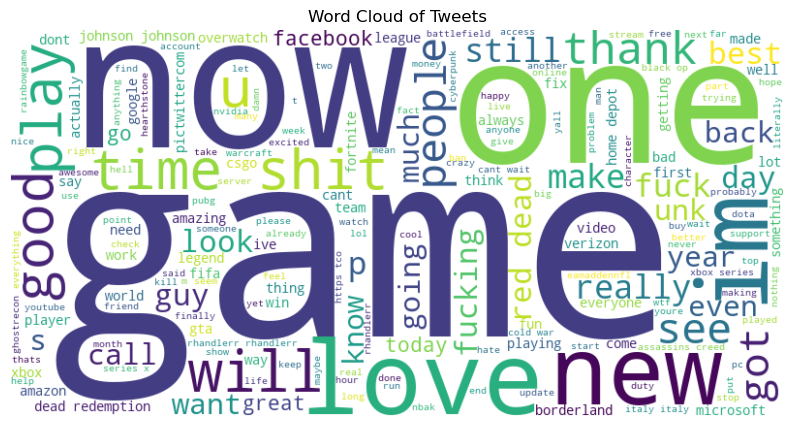

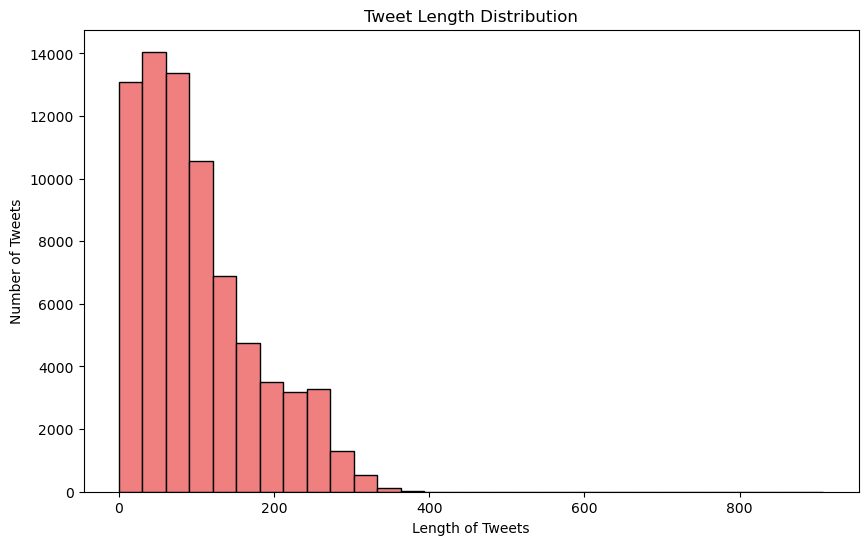

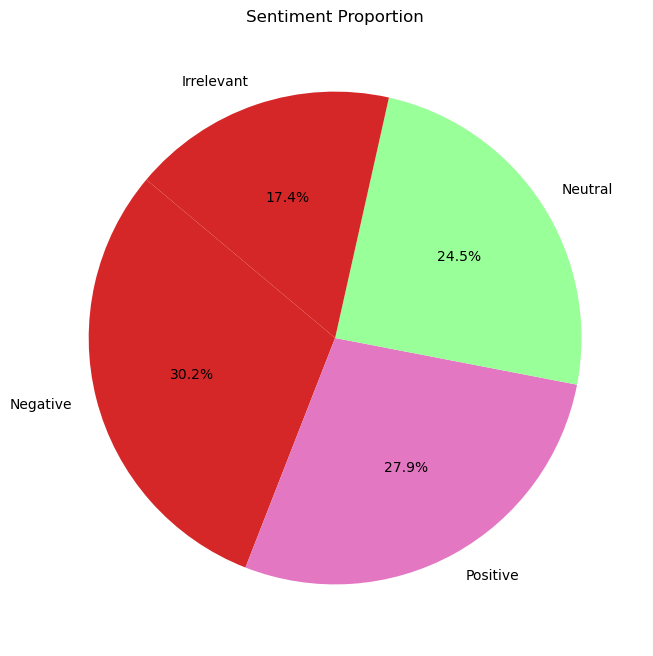